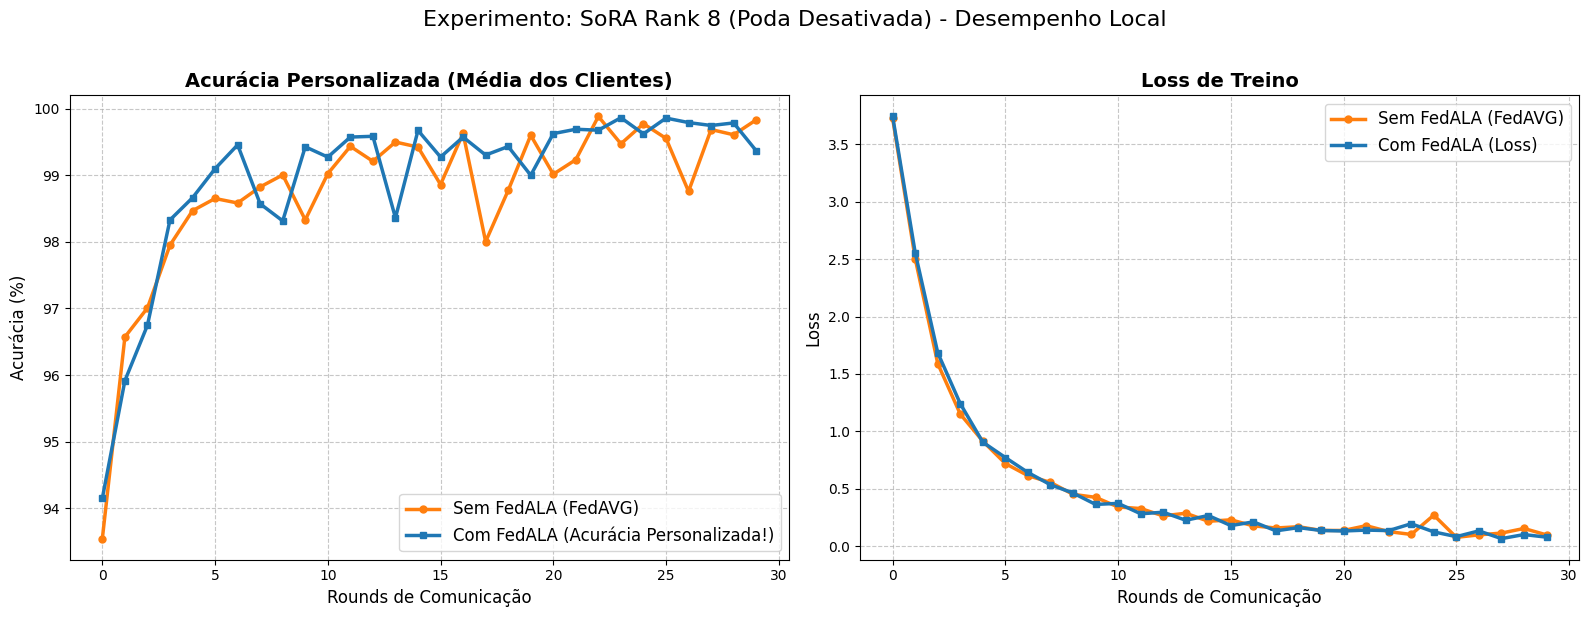

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Pasta onde os resultados foram salvos
res_dir = Path("dados_compartilhados")

def load_metrics(mode):
    """
    mode: "FedAVG" (sem ALA) ou "FedALA" (com ALA)
    """
    pers_accs = []
    losses = []
    
    for i in range(5):
        # Nome EXATO dos arquivos listados no seu terminal
        filepath = res_dir / f"OxfordPets_sora_with_schedule_rank8_paca0_{mode}_client_{i}_run1.h5"
        
        if filepath.exists():
            with h5py.File(filepath, "r") as f:
                # Tenta buscar a Acurácia Personalizada, se não achar cai pro Global
                if 'rs_personalized_acc' in f:
                    pers_accs.append(np.array(f['rs_personalized_acc']))
                else:
                    pers_accs.append(np.array(f["rs_test_acc"]))
                    
                losses.append(np.array(f["rs_train_loss"])) 
        else:
            print(f"⚠️ Arquivo não encontrado: {filepath.name}")
    
    if len(pers_accs) == 0:
        return None, None
        
    return np.mean(pers_accs, axis=0), np.mean(losses, axis=0)

# Carrega as médias para os dois modos
pers_avg, loss_avg = load_metrics("FedAVG")
pers_ala, loss_ala = load_metrics("FedALA")

if pers_avg is not None and pers_ala is not None:
    # Cria os gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Gráfico de Acurácia ---
    ax1.plot(pers_avg, label="Sem FedALA (FedAVG)", linewidth=2.5, marker='o', markersize=5, color='#ff7f0e')
    ax1.plot(pers_ala, label="Com FedALA (Acurácia Personalizada!)", linewidth=2.5, marker='s', markersize=5, color='#1f77b4')
    ax1.set_title("Acurácia Personalizada (Média dos Clientes)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Rounds de Comunicação", fontsize=12)
    ax1.set_ylabel("Acurácia (%)", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend(fontsize=12, loc='lower right')

    # --- Gráfico de Loss ---
    ax2.plot(loss_avg, label="Sem FedALA (FedAVG)", linewidth=2.5, marker='o', markersize=5, color='#ff7f0e')
    ax2.plot(loss_ala, label="Com FedALA (Loss)", linewidth=2.5, marker='s', markersize=5, color='#1f77b4')
    ax2.set_title("Loss de Treino", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Rounds de Comunicação", fontsize=12)
    ax2.set_ylabel("Loss", fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(fontsize=12, loc='upper right')

    plt.suptitle("Experimento: SoRA Rank 8 (Poda Desativada) - Desempenho Local", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("❌ Falha ao carregar os dados. Verifique se as simulações terminaram.")
